In [9]:
import qsample as qs
import time
import stim
import numpy as np
import matplotlib.pyplot as plt
import pymatching

## Repetition code

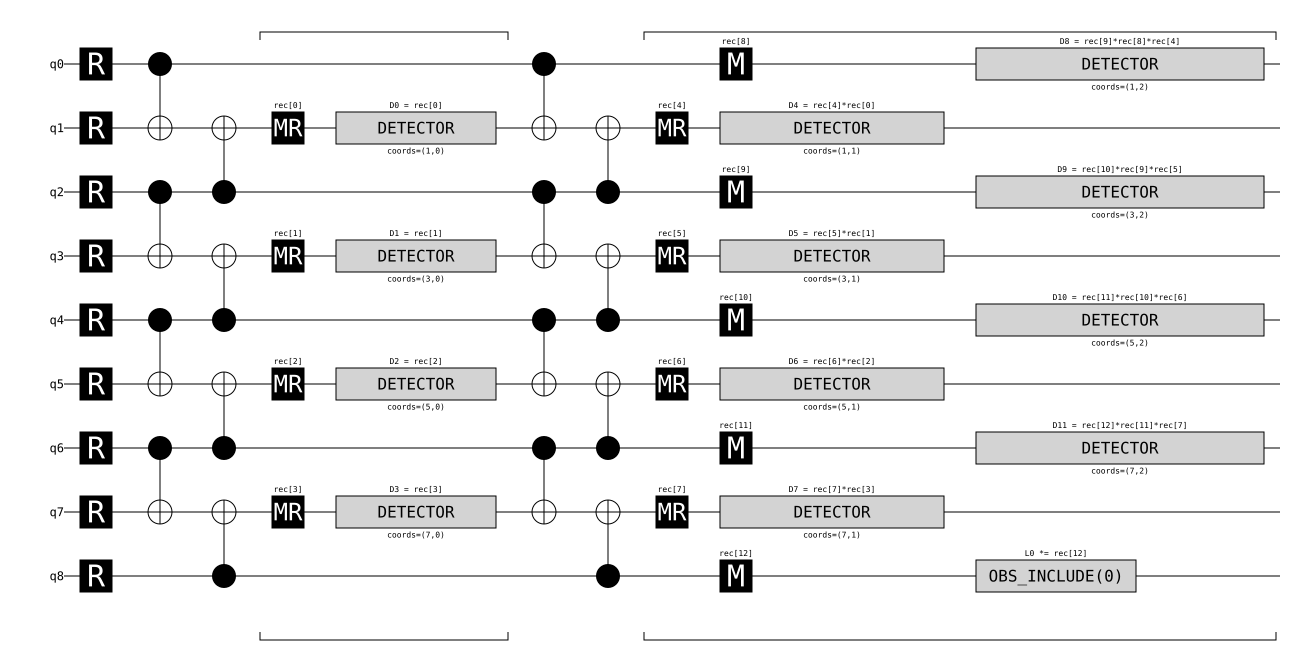

In [10]:
code = stim.Circuit.generated("repetition_code:memory", rounds=2, distance=5)
rep_code = qs.Circuit(noisy=True).from_stim_circuit(code)

code.diagram('timeline-svg')

p=('1.00e-01',): 100%|██████████| 200/200 [00:00<00:00, 9618.53it/s]


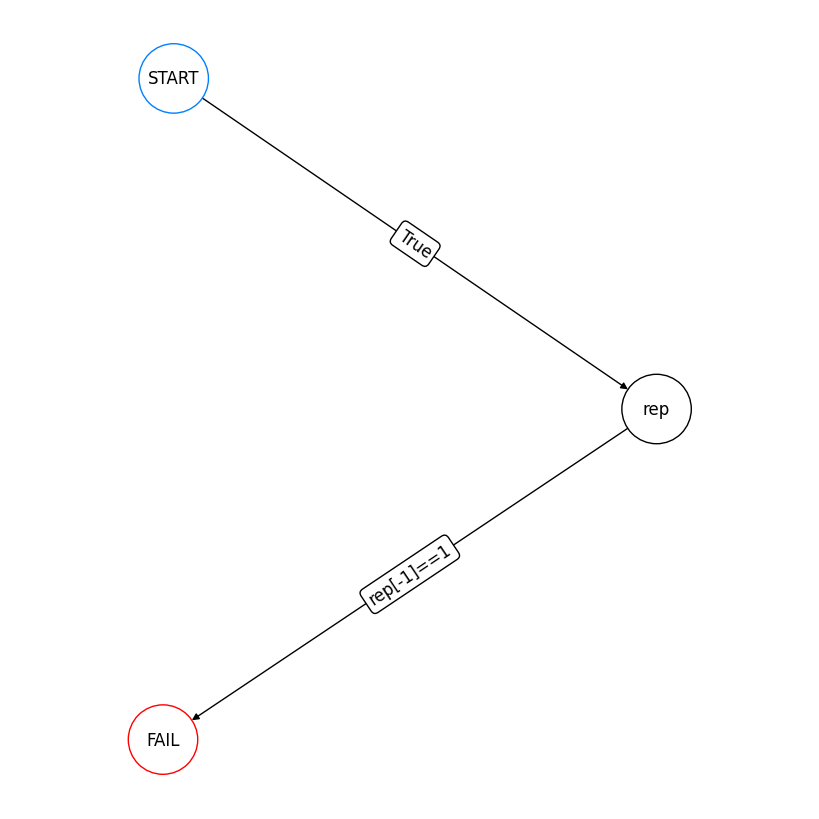

In [11]:
distance = 5
code = stim.Circuit.generated("repetition_code:memory", rounds=1, distance=distance, before_round_data_depolarization=0.01,
              before_measure_flip_probability=0.01)
rep_code = qs.Circuit(noisy=True).from_stim_circuit(code)

DEM = code.detector_error_model(decompose_errors=True)
decoder = pymatching.Matching.from_detector_error_model(DEM)

functions = {}
rep = qs.Protocol(check_functions=functions)

rep.add_nodes_from(['rep'], circuits=[rep_code])
rep.add_edge('START', 'rep', check='True')
rep.add_edge('rep', 'FAIL', check='rep[-1]==1')


rep.draw(figsize=(8,8), path='protocol_repetition')

err_model = qs.noise.E1
stim_sam = qs.LifetimeSampler(200, protocol=rep, simulator=qs.StimSimulator,  p_max={'q': [0.1]}, err_model=err_model, distance=distance)

In [12]:
stim_sam.calculate_lifetime(8, 500, 0.01)

5.088

## Toy model

In [13]:
toy_code = qs.Circuit([{"init": {0}}, {"I":{0}}, {"measure": {0}}], noisy=True)
toy = qs.Protocol(check_functions={})

toy.add_nodes_from(['toy'], circuits=[toy_code])
toy.add_edge('START', 'toy', check='True')
toy.add_edge('toy', 'FAIL', check='toy[-1]==1')

err_model = qs.noise.E1
toy_sam = qs.LifetimeSampler(2000, protocol=toy, simulator=qs.StimSimulator,  p_max={'q': [0.1]}, err_model=err_model, distance=distance)
toy_sam.calculate_lifetime(50, 1000, 0.12)

p=('1.00e-01',): 100%|██████████| 2000/2000 [00:00<00:00, 20720.44it/s]


12.136

In [14]:
p_phys = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
lifetimes = []
for p in p_phys:
    lifetime = toy_sam.calculate_lifetime(50, 1000, p)
    print(lifetime)
    lifetimes.append(lifetime)

14.725
11.483
9.302
7.426
6.536
5.731


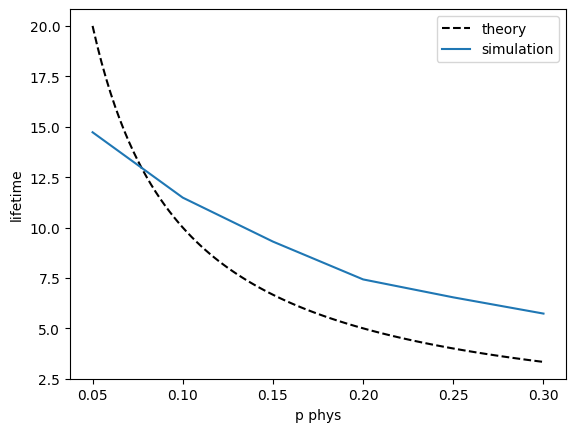

In [15]:
x = np.linspace(0.05, 0.3, 101)
plt.plot(x, 1/x, 'k--', label = 'theory')
plt.plot(p_phys, lifetimes, label='simulation')
plt.xlabel('p phys')
plt.ylabel('lifetime')
plt.legend()